# ml class double pendulum control problem

setup

In [1]:
# only need it once
#!pip install gymnasium[classic-control]

In [1]:
import gymnasium as gym
import numpy as np
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [2]:
name = "Acrobot-v1"
env = gym.make(name)

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

# Hyperparameters from the PyTorch tutorial
# OPTIMIZE THESE LATER
BATCH_SIZE = 28
GAMMA = 0.99 # reward decay
# exploration epsilons
EPS_START = 0.9 
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005 # idk
LR = 3e-4 # learning rate

# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = len(state)

episode_durations = []

def plot_durations(episode_durations,show_result=False):
    # continuously updating plot of episode duration
    # trying to get this under some target value consistently
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [3]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward')) # simplicity

class ReplayMemory(object):
    # holds the last n transitions for training later

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


# make the model
class DQN(nn.Module):
    def __init__(self, width=128, depth=2):
        # nominal 128 width w/ one hidden layer
        super(DQN, self).__init__()
        self.layers = [nn.Linear(n_observations,width), nn.ReLU()] # start with one layer to take in my 6 observation points
        for _ in range(depth-1):
            self.layers.append(nn.Linear(width,width))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(width,n_actions)) # end with 3 nodes for my three actions
        # Linear regression model
        self.model = nn.Sequential(*self.layers)

    def forward(self,x):
        return self.model(x)
        
'''
def new_model(width=6, depth=1):
    layers = [nn.Linear(6,width), nn.ReLU()] # start with one layer to take in my 6 observation points
    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(width,3)) # end with 3 nodes for my three actions
    # Linear regression model
    model = nn.Sequential(*layers)
    return model

# function to choose the action based on what my model says
def choose(model, state):
    # takes in a 1x3
    # grab the max and output -1,0,1
    out = model(state)
    actions = [-1,0,1]
    action = actions[torch.argmax(out)]
    return action  

def opt():
    exp = choose(target, torch.tensor(state))
    
    # Forward pass
    loss = criterion(policy(state),target(state))
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
'''
# start up both networks
policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

# Adam optimizer
optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0


def choose(state, EPS_START, EPS_END, EPS_DECAY):
    global steps_done
    global policy_net
    sample = random.random()
    # greedy exploration, with decreasing odds as time goes on
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1.0 * steps_done / EPS_DECAY)
    steps_done += 1
    # returns either the policy's decision or random decision
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

def optimize_model(BATCH_SIZE, GAMMA, memory):
    global policy_net
    global target_net
    global optimizer
    # only start optimizing if theres enough memories
    if len(memory) < BATCH_SIZE:
        #print(BATCH_SIZE,len(memory))
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    # some subgroups for later
    # plus a mask to take out anything that is an end state
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # get policy net values for the actions taken by the memories
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # estimate next state values from target net 
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values

    # expected values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # huber loss 
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    # gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

In [4]:
# i think its easier to just make a big dataclass of these and then i can just throw that into the function instead of anything else
from dataclasses import dataclass
@dataclass
class Hypers:
    BATCH_SIZE: int=28
    GAMMA: float=0.99
    EPS_START: float=0.9
    EPS_END: float = 0.01
    EPS_DECAY: int = 2500
    TAU: float = .005
    LR: float = 3e-4
    num_episodes: int = 50
    width: int = 128
    depth: int = 2

# named tuples dont have defaults
# Hypers = namedtuple('Hypers', ('BATCH_SIZE','GAMMA','EPS_START','EPS_END','EPD_DECAY','TAU','LR', 'num_episodes','width','depth'))

In [5]:
full_obs = []
#full_reward = []
full_durations = []

# one run
def full_run(Hyper):
    global full_obs
    #global full_reward
    global full_durations
    global policy_net
    global target_net
    global optimizer
    global steps_done
    # start up both networks
    policy_net = DQN(Hyper.width, Hyper.depth).to(device)
    target_net = DQN(Hyper.width, Hyper.depth).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    
    # Adam optimizer
    optimizer = optim.AdamW(policy_net.parameters(), lr=Hyper.LR, amsgrad=True)
    memory = ReplayMemory(10000)

    episode_durations = []
    run_obs = []
    run_durations = []
    #ep_rew = []
    ep_obs = []

    plt.ion()
    plt.clf()
    
    steps_done = 0
    
    for i_episode in range(Hyper.num_episodes):
        state, info = env.reset()
        #ep_rew = [0]
        ep_obs = [torch.tensor(state, dtype=torch.float32)]
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
        for t in count():
            # do stuff
            action = choose(state, Hyper.EPS_START, Hyper.EPS_END, Hyper.EPS_DECAY)
            observation, reward, terminated, truncated, _ = env.step(action.item())
            reward = torch.tensor([reward], device=device)
            done = terminated or truncated
            
            #ep_obs.append(observation)
            ep_obs.append(torch.tensor(observation, dtype=torch.float32))
            #ep_rew.append(ep_rew[-1]+reward) # adds to rolling total
            
            # did we win
            if terminated:
                next_state = None
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    
            memory.push(state, action, next_state, reward)
    
            state = next_state
    
            optimize_model(Hyper.BATCH_SIZE, Hyper.GAMMA, memory)
    
            # update target model to be closer to policy model
            # by factor of tau
            target_net_state_dict = target_net.state_dict()
            policy_net_state_dict = policy_net.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key] * Hyper.TAU + target_net_state_dict[key] * (1 - Hyper.TAU)
            target_net.load_state_dict(target_net_state_dict)
    
            if done:
                episode_durations.append(torch.tensor((t + 1),dtype=int))
                #print(t+1)
                #print(policy_net.layers[0].weight[1])
                #plot_durations(episode_durations)
                #run_obs.append(ep_obs)
                ep = torch.stack(ep_obs)
                ep = torch.cat([ep, ep[-1:].expand(501-ep.shape[0], -1)], dim=0)
                run_obs.append(torch.tensor(ep, dtype=torch.float32))
                #full_reward.append(ep_rew)
                #run_durations.append(episode_durations)
                break

    robs = torch.stack(run_obs)
    full_obs.append(robs)
    durs = torch.stack(episode_durations)
    full_durations.append(durs)
    print('Complete')
    plot_durations(episode_durations,show_result=True)
    plt.ioff()
    plt.show()

C:\Users\snyde\AppData\Local\Temp\ipykernel_17456\2757584090.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  run_obs.append(torch.tensor(ep, dtype=torch.float32))


Complete


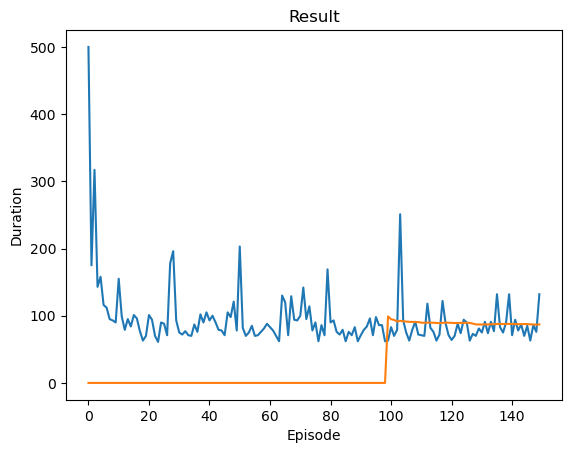

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
# gpu stuff
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 500
else:
    num_episodes = 50
full_obs = []
#full_reward = []
full_durations = []

hyper = Hypers(num_episodes=150, BATCH_SIZE= 110, GAMMA= 0.9976956136276068, EPS_START= 0.9993857359941088, EPS_END= 0.011192580743242699, EPS_DECAY= 400, TAU= 0.02466313712462127, LR= 0.0009258114241697843, width= 135)
full_run(hyper)

full_obs = torch.stack(full_obs)
full_durations = torch.stack(full_durations)

In [8]:
print("")
'''
# gpu stuff
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 500
else:
    num_episodes = 50

full_obs = [state]
full_reward = [0]
state = torch.from_numpy(state)

policy = new_model(width, depth)
target = new_model(width, depth)
# Loss and optimizer
criterion = nn.MSELoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(policy.parameters(), lr=learning_rate)

for t in range(500): # 500 timesteps
    
    action = choose(policy,torch.tensor(state)) # can be -1 0 1 to apply torque in direction
    observation, reward, terminated, truncated, info = env.step(action) # current state, reward from state, did it win, did it run out of time
    full_obs.append(observation)
    full_reward.append(full_reward[-1]+reward) # adds to rolling total

    
    state = torch.from_numpy(observation)
    opt()
    
    img.set_data(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)
    
    if terminated or truncated:
        break
env.close()
'''

'\n# gpu stuff\nif torch.cuda.is_available() or torch.backends.mps.is_available():\n    num_episodes = 500\nelse:\n    num_episodes = 50\n\nfull_obs = [state]\nfull_reward = [0]\nstate = torch.from_numpy(state)\n\npolicy = new_model(width, depth)\ntarget = new_model(width, depth)\n# Loss and optimizer\ncriterion = nn.MSELoss()\nlearning_rate = 0.1\noptimizer = torch.optim.SGD(policy.parameters(), lr=learning_rate)\n\nfor t in range(500): # 500 timesteps\n\n    action = choose(policy,torch.tensor(state)) # can be -1 0 1 to apply torque in direction\n    observation, reward, terminated, truncated, info = env.step(action) # current state, reward from state, did it win, did it run out of time\n    full_obs.append(observation)\n    full_reward.append(full_reward[-1]+reward) # adds to rolling total\n\n\n    state = torch.from_numpy(observation)\n    opt()\n\n    img.set_data(env.render())\n    display.display(plt.gcf())\n    display.clear_output(wait=True)\n\n    if terminated or truncated:\

(150, 501)


C:\Users\snyde\AppData\Local\Temp\ipykernel_17456\2514715516.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  full_obs_np = np.array(full_obs, dtype=np.float32)
C:\Users\snyde\AppData\Local\Temp\ipykernel_17456\2514715516.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  epn = np.array(full_durations[i], dtype=np.float32)


<Figure size 640x480 with 0 Axes>

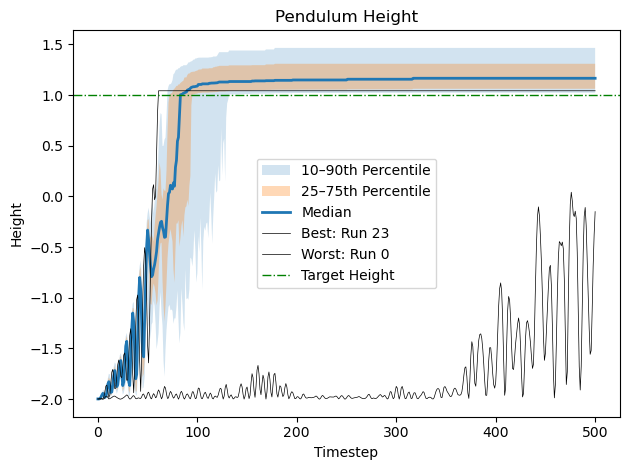

C:\Users\snyde\AppData\Local\Temp\ipykernel_17456\2514715516.py:45: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  epn = np.array(full_durations[i], dtype=np.float32)
C:\Users\snyde\AppData\Local\Temp\ipykernel_17456\2514715516.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  epn = np.array(epn)


[np.float64(0.831941093482694)]


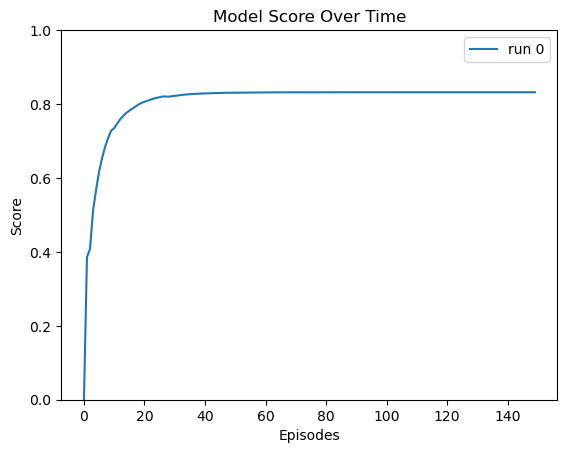

In [16]:
%matplotlib inline 

full_obs_np = np.array(full_obs, dtype=np.float32)
#full_reward = [int(full_reward[i]) for i in range(len(full_reward))]
# height = -(l1*cos(t1) + l2*(cos(t1)*cos(t2)-sin(t1)*sin(t2)))
# trying to get to height = 1 (not pointing straight up, just over a designated height)
l1 = 1
l2 = 1 # these are set in the thingy
height = -(l1*full_obs_np[:,:,:,0] + l2*(full_obs_np[:,:,:,0]*full_obs_np[:,:,:,2] - full_obs_np[:,:,:,1]*full_obs_np[:,:,:,3]))
means = np.mean(height,0)
print(means.shape)

for i,run in enumerate(height):
    plt.figure()
    epn = np.array(full_durations[i], dtype=np.float32)
    
    #plot height
    timesteps = np.arange(run.shape[1])
    mean = np.median(run, axis=0)
    p25, p75 = np.percentile(run, [25, 75], axis=0)
    p10, p90 = np.percentile(run, [10, 90], axis=0)
    best = run[np.argmin(epn)]
    worst = run[np.argmax(epn)]
    
    fig, ax = plt.subplots()
    
    ax.fill_between(timesteps, p10, p90, alpha=0.2, label='10–90th Percentile')
    ax.fill_between(timesteps, p25, p75, alpha=0.3, label='25–75th Percentile')
    ax.plot(timesteps, mean, label='Median', linewidth=2)
    ax.plot(best, label=f'Best: Run {np.argmin(epn)}', color='black', linewidth=0.5)
    ax.plot(worst, label=f'Worst: Run {np.argmax(epn)}', color='black', linewidth=0.5)
    ax.axhline(y=1.0, color='green', linestyle='-.', linewidth=1, label='Target Height')
    
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Height")
    ax.set_title("Pendulum Height")
    ax.legend()
    plt.tight_layout()
    plt.show()



plt.figure()
for i,run in enumerate(height):
    epn = np.array(full_durations[i], dtype=np.float32)
    def dec(n, lam=0.1):
        r = math.exp(-lam)          # ratio per step
        return r * (1 - r**n) / (1 - r)
    test3 = [(500-1/dec(i+1)*np.sum([ep*np.exp(-0.1*(j+1)) for j,ep in enumerate(epn[0:i+1])]))/(500-100) for i in range(len(epn))]
    plt.plot(test3, label = f'run {i}')
plt.ylim(0,1)
plt.ylabel('Score')
plt.xlabel('Episodes')
plt.title('Model Score Over Time')
plt.legend()

def score(epn):
    epn = np.array(epn)
    return (500-1/dec(len(epn)+1)*np.sum([ep*np.exp(-0.1*(j+1)) for j,ep in enumerate(epn)]))/(500-100)
scores = [score(run) for run in full_durations]
print(scores)

In [ ]:
# Flatten all episodes, but track which test each came from
all_episodes = []
test_indices = []

for test_idx, test in enumerate(full_obs):
    for ep in test:
        all_episodes.append(ep)
        test_indices.append(test_idx)

# Build padded tensor and mask
#max_len = max(ep.shape[0] for ep in all_episodes)
max_len = 500
#state_dim = all_episodes[0].shape[1]
state_dim = 6
n = len(all_episodes)

padded = torch.zeros(n, max_len, state_dim)
mask = torch.zeros(n, max_len)

for i, ep in enumerate(all_episodes):
    t = ep.shape[0]
    padded[i, :t, :] = ep
    mask[i, :t] = 1.0

test_indices = torch.tensor(test_indices)  # shape (n,)

def mean_ci(padded, mask, episode_mask=None, z=1.96):
    """
    episode_mask: boolean tensor of shape (n,) selecting which episodes to include.
                  If None, uses all episodes.
    z: 1.96 for 95% CI, 2.576 for 99% CI
    Returns: mean, lower_ci, upper_ci — each shape (max_len, state_dim)
    """
    if episode_mask is not None:
        p = padded[episode_mask]
        m = mask[episode_mask]
    else:
        p, m = padded, mask

    m = m.unsqueeze(-1)                      # (n, max_len, 1)
    counts = m.sum(0).clamp(min=1)           # (max_len, 1)
    mean = (p * m).sum(0) / counts           # (max_len, state_dim)

    # Standard error across episodes at each timestep
    variance = ((p - mean.unsqueeze(0)) ** 2 * m).sum(0) / counts
    se = (variance / counts).sqrt()

    return mean, mean - z * se, mean + z * se

m,l,h = mean_ci(padded,mask)
%matplotlib inline

m = m.numpy()
l = l.numpy()
h = h.numpy()
time = np.arange(mean.shape[0])
plt.plot(time,m)
plot.fill_between(time,l,h)

90
Video saved to the 'videos' folder.


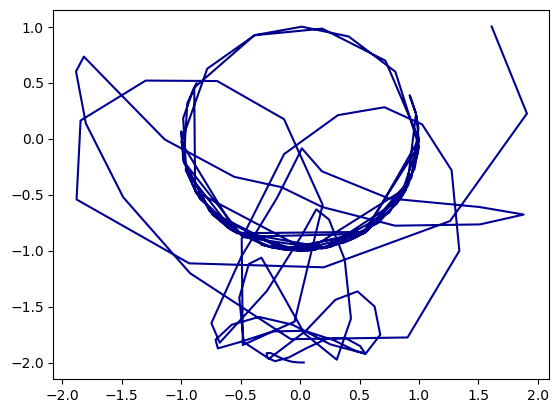

In [18]:
import gymnasium as gym
from gymnasium.utils.save_video import save_video
import torch

# Set up the environment with rgb_array for recording
env = gym.make(name, render_mode="rgb_array_list")

state, _ = env.reset()
step_starting_index = 0
episode_index = 0
done = False
end_obs = [torch.tensor(state, dtype=torch.float32)]

while not done:
    with torch.no_grad():
        # Convert state to tensor and move to the same device as the policy network
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        action = policy_net(state_t).max(1).indices.view(1, 1)

    state, reward, terminated, truncated, _ = env.step(action)
    end_obs.append(torch.tensor(state, dtype=torch.float32))
    done = terminated or truncated

end_obs_np = np.array(end_obs)

x1 = end_obs_np[:,1]
y1 = -end_obs_np[:,0]

x2 = end_obs_np[:,1] + end_obs_np[:,1]*end_obs_np[:,2] + end_obs_np[:,0]*end_obs_np[:,3]
y2 = -(end_obs_np[:,0] + end_obs_np[:,0]*end_obs_np[:,2] - end_obs_np[:,1]*end_obs_np[:,3])

end_x = [np.zeros(len(x2)), x1, x2]
end_y = [np.zeros(len(y2)), y1, y2]
colors = plt.cm.jet(np.linspace(0,1,len(x2)))
for i,x in enumerate(end_x):
    plt.plot(x, end_y[i], c=colors[i])
print(len(x1))

# Save the recorded frames as a video
save_video(
    env.render(),
    "videos",
    fps=30,
    episode_index=episode_index,
    name_prefix="acrobot-run"
)

env.close()

print("Video saved to the 'videos' folder.")

he wants to see a plot of state-action-reward sequences, we can just manually define some right now